# Model Preparation 02 — Feature Selection

**Goal:** Select the final feature set for ML training by eliminating:
1. Leakage columns (from `01_leakage_and_target_definition`)
2. Multicollinear features (Variance Inflation Factor > 10)
3. Features with no signal (Mutual Information ≈ 0)

**Tables:** gold_card_features, gold_price_features

**Prerequisite:** Run `01_leakage_and_target_definition.ipynb` first — it produces `leakage_config.json`.

**Note on MI proxy:** With only 5 snapshots, there are no t+7 log-return targets yet. Mutual
Information is therefore computed against `log1p(eur)` (price level) as a proxy. Features that
explain price magnitude are likely to also explain price changes — but the MI ranking may shift
once return data is available (particularly for short-term momentum features). Re-run at ≥8 snapshots.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import json
import warnings

In [2]:
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

with open("leakage_config.json") as f:
    leakage_cfg = json.load(f)
leakage_cols = leakage_cfg["leakage"]
risky_cols = leakage_cfg["risky"]
print(
    f"Loaded leakage_config.json: {len(leakage_cols)} leakage, {len(risky_cols)} risky columns"
)

Loaded leakage_config.json: 3 leakage, 6 risky columns


## 1. NULL Rates per Feature and Imputation Strategy

**Problem:** Cards imported only from Scryfall (no MTGJson match) have NULL for most static
card attributes (`is_reserved`, `is_reprint`, `mana_value`, etc.). These represent ~81% of rows.

**Imputation strategies:**
- Boolean attributes (`is_reserved`, `is_reprint`, `is_promo`, etc.): fill `False`  
  — a Scryfall-only card is not on the Reserved List (MTGJson is the authoritative source for this)
- Numeric attributes (`edhrec_rank`, `mana_value`): fill with median per rarity  
  — MNAR: cards without an EDHREC rank tend to be unplayed bulk, not a random sample
- Add `has_mtgjson_data` binary feature to capture the Scryfall-only vs MTGJson-matched distinction

**Critical scope rule:** Fit imputers only on the training fold, apply (transform only) to
validation and test. Fitting on future data is preprocessing leakage.

In [3]:
# Use the last snapshot as a cross-section for NULL analysis and VIF/MI computation.
# JOIN brings in static card attributes; LEFT JOIN preserves Scryfall-only cards.
df = gold.execute("""
    SELECT pf.uuid, pf.eur, pf.price_7d_avg, pf.price_30d_avg,
           pf.price_change_1d_pct, pf.price_volatility_30d,
           pf.price_rank_global, pf.foil_premium,
           cf.rarity, cf.mana_value, cf.is_reserved, cf.is_reprint,
           cf.is_promo, cf.is_full_art, cf.is_textless, cf.edhrec_saltiness,
           cf.finish_count, cf.has_etched_finish, cf.color_count,
           cf.color_identity_count, cf.variation_count, cf.is_commander_legal,
           cf.is_standard_legal, cf.is_modern_legal, cf.is_legacy_legal,
           cf.format_count, cf.print_count
    FROM gold_price_features pf
    LEFT JOIN gold_card_features cf ON pf.uuid = cf.uuid
    WHERE pf.eur IS NOT NULL AND pf.uuid IS NOT NULL
      AND pf.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
""").df()

# Candidate features: static card attributes + safe price-derived features.
# Leakage columns (price_ath, price_atl, days_with_price) are excluded by construction.
candidate_features = [
    "mana_value",
    "edhrec_saltiness",
    "format_count",
    "print_count",
    "finish_count",
    "color_count",
    "color_identity_count",
    "variation_count",
    "is_reserved",
    "is_reprint",
    "is_promo",
    "is_full_art",
    "is_textless",
    "has_etched_finish",
    "is_commander_legal",
    "is_standard_legal",
    "is_modern_legal",
    "is_legacy_legal",
    "price_7d_avg",
    "price_30d_avg",
    "price_change_1d_pct",
    "price_volatility_30d",
    "price_rank_global",
    "foil_premium",
]
candidates = [c for c in candidate_features if c in df.columns]
print(f"Candidate features: {len(candidates)}")
print(f"Dataset rows (last snapshot): {len(df):,}")

# NULL rate per feature.
null_rates = df[candidates].isna().mean() * 100
null_df = null_rates.sort_values(ascending=False).rename("null_%").to_frame()
null_df["dtype"] = df[candidates].dtypes
null_df["n_non_null"] = df[candidates].notna().sum()
display(null_df[null_df["null_%"] > 0])

# has_mtgjson_data: True when MTGJson data is available (is_reserved is a reliable proxy).
# This feature captures the systematic quality difference between Scryfall-only and MTGJson-matched cards.
df["has_mtgjson_data"] = df["is_reserved"].notna().astype(int)
candidates.append("has_mtgjson_data")
print(
    f"\nhas_mtgjson_data=1 (MTGJson-matched cards): {df['has_mtgjson_data'].mean() * 100:.1f}%"
)

# Document the imputation strategy — implemented in the training pipeline, not here.
imputation_strategy = {
    "is_reserved": ("fill_false", "Not on Reserved List if no MTGJson entry"),
    "is_reprint": ("fill_false", "Not a reprint if no MTGJson entry"),
    "is_promo": ("fill_false", "Not a promo if no MTGJson entry"),
    "is_full_art": ("fill_false", "Not full art if no MTGJson entry"),
    "is_textless": ("fill_false", "Not textless if no MTGJson entry"),
    "has_etched_finish": ("fill_false", "No etched finish if no MTGJson entry"),
    "edhrec_saltiness": ("median", "Unrated cards default to median saltiness"),
    "mana_value": ("median_per_rarity", "Scryfall-only cards span all types"),
    "foil_premium": ("fill_1.0", "No foil premium if foil price absent (ratio = 1)"),
}
print(
    "\nImputation strategy (to be implemented in the sklearn pipeline at training time):"
)
for col, (strategy, note) in imputation_strategy.items():
    if col in candidates:
        print(f"  {col:<25}: {strategy:<22}  ({note})")

Candidate features: 24
Dataset rows (last snapshot): 80,757


,null_%,dtype,n_non_null
is_standard_legal,82.940179,boolean,13777
foil_premium,42.827247,float32,46171
is_modern_legal,24.995976,boolean,60571
is_legacy_legal,2.568198,boolean,78683
is_commander_legal,2.460468,boolean,78770
edhrec_saltiness,0.500266,float64,80353



has_mtgjson_data=1 (MTGJson-matched cards): 100.0%

Imputation strategy (to be implemented in the sklearn pipeline at training time):
  is_reserved              : fill_false              (Not on Reserved List if no MTGJson entry)
  is_reprint               : fill_false              (Not a reprint if no MTGJson entry)
  is_promo                 : fill_false              (Not a promo if no MTGJson entry)
  is_full_art              : fill_false              (Not full art if no MTGJson entry)
  is_textless              : fill_false              (Not textless if no MTGJson entry)
  has_etched_finish        : fill_false              (No etched finish if no MTGJson entry)
  edhrec_saltiness         : median                  (Unrated cards default to median saltiness)
  mana_value               : median_per_rarity       (Scryfall-only cards span all types)
  foil_premium             : fill_1.0                (No foil premium if foil price absent (ratio = 1))


## 2. VIF — Detecting Multicollinearity

**Method:** Variance Inflation Factor (VIF) per feature. VIF > 10 signals strong multicollinearity
with other features in the set.

**Why VIF instead of pairwise correlation:**
Pearson correlation detects pairs. VIF detects whether a feature is a near-linear combination of
*multiple* other features simultaneously. A triplet with pairwise r = 0.6 can produce VIF = 20
without any single pair exceeding the threshold — VIF catches this; a correlation matrix does not.

**Known multicollinearity (from CDA):**
- `is_legacy_legal` and `is_modern_legal` are correlated with `format_count`
- `is_commander_legal` correlates strongly with `is_legacy_legal`

**Decision:** When two features are highly collinear, keep the one with higher MI (section 3)
or replace both with an aggregate (e.g., `format_count` instead of individual `is_X_legal` columns).

In [4]:
# Prepare a fully numeric matrix for VIF computation.
# Simple median imputation is used here only — the production pipeline uses the
# per-rarity strategy from section 1.
X_vif = df[candidates].copy()

bool_cols = X_vif.select_dtypes(include="bool").columns.tolist()
X_vif[bool_cols] = X_vif[bool_cols].astype(float)
X_vif = X_vif.apply(pd.to_numeric, errors="coerce")
X_vif = X_vif.dropna(axis=1, how="all")
X_vif = X_vif.fillna(X_vif.median())

# Drop zero-variance columns — VIF is undefined when std=0.
X_vif = X_vif.loc[:, X_vif.std() > 0]

print(f"Features entering VIF computation: {X_vif.shape[1]}")
print(f"Rows: {X_vif.shape[0]:,}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vif_values = [
        variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
    ]

vif_df = (
    pd.DataFrame({"feature": X_vif.columns, "VIF": vif_values})
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)
display(vif_df)

high_vif = vif_df[vif_df["VIF"] > 10]
print(f"\nFeatures with VIF > 10 (multicollinear): {high_vif['feature'].tolist()}")
print(
    "Recommendation: drop or replace with an aggregate (e.g., format_count for is_X_legal columns)."
)

Features entering VIF computation: 22
Rows: 80,757


,feature,VIF
0,price_30d_avg,inf
1,price_7d_avg,inf
2,is_standard_legal,621.595624
3,is_commander_legal,480.201596
4,is_modern_legal,278.745530
5,is_legacy_legal,187.457547
6,finish_count,16.360454
7,format_count,11.182730
8,color_identity_count,7.935953
9,color_count,7.489574



Features with VIF > 10 (multicollinear): ['price_30d_avg', 'price_7d_avg', 'is_standard_legal', 'is_commander_legal', 'is_modern_legal', 'is_legacy_legal', 'finish_count', 'format_count']
Recommendation: drop or replace with an aggregate (e.g., format_count for is_X_legal columns).


## 3. Mutual Information — Signal Ranking per Feature

**Method:** `mutual_info_regression(X, y)` — measures information each feature carries about the target.

**Target proxy:** `log1p(eur)` at the latest snapshot, used because no t+7 log-return data exists yet.
Features explaining price *level* are likely relevant to price *changes*, but the ranking may shift
for momentum-type features once return data arrives.

**Robustness:** MI uses a k-NN estimator with a random component. Running 3 seeds and averaging
reduces the noise in the ranking.

**Decision rule:**
- `MI > 0.10` and `VIF < 10` and not leakage → **INCLUDE**
- `MI > 0.05` and `VIF 10–20` → **INCLUDE with caution** (review collinearity manually)
- `MI < 0.05` or LEAKAGE → **EXCLUDE**

,feature,MI
0,price_30d_avg,5.346435
1,price_7d_avg,5.346435
2,price_rank_global,5.320795
3,foil_premium,0.863838
4,edhrec_saltiness,0.151480
5,format_count,0.126840
6,print_count,0.116232
7,variation_count,0.065482
8,is_full_art,0.053224
9,finish_count,0.044385


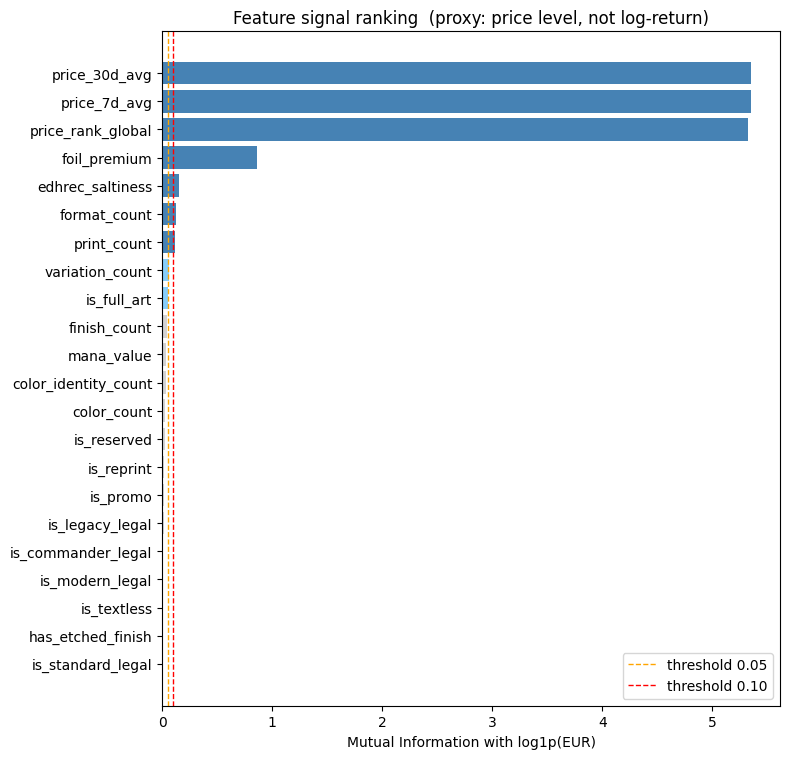


Features with MI < 0.05 (no signal, candidates for removal): ['finish_count', 'mana_value', 'color_identity_count', 'color_count', 'is_reserved', 'is_reprint', 'is_promo', 'is_legacy_legal', 'is_commander_legal', 'is_modern_legal', 'is_textless', 'has_etched_finish', 'is_standard_legal']


In [5]:
y = np.log1p(df["eur"].values)

# Use the already-imputed X_vif matrix to ensure MI operates on the same feature set as VIF.
X_mi = X_vif.copy()

# Average over 3 seeds to reduce estimator variance.
mi_runs = []
for seed in [42, 123, 999]:
    mi = mutual_info_regression(X_mi.values, y, random_state=seed)
    mi_runs.append(mi)
mi_mean = np.mean(mi_runs, axis=0)

mi_df = (
    pd.DataFrame({"feature": X_mi.columns, "MI": mi_mean})
    .sort_values("MI", ascending=False)
    .reset_index(drop=True)
)
display(mi_df)

# Colour code: dark blue = high signal, light blue = borderline, grey = no signal.
colors = [
    "steelblue" if v > 0.10 else "lightskyblue" if v > 0.05 else "lightgrey"
    for v in mi_df["MI"]
]

fig, ax = plt.subplots(figsize=(8, max(4, len(mi_df) * 0.35)))
ax.barh(mi_df["feature"][::-1], mi_df["MI"][::-1], color=colors[::-1])
ax.axvline(0.05, color="orange", linestyle="--", linewidth=1, label="threshold 0.05")
ax.axvline(0.10, color="red", linestyle="--", linewidth=1, label="threshold 0.10")
ax.set_xlabel("Mutual Information with log1p(EUR)")
ax.set_title("Feature signal ranking  (proxy: price level, not log-return)")
ax.legend()
plt.tight_layout()
plt.show()

low_mi = mi_df[mi_df["MI"] < 0.05]["feature"].tolist()
print(f"\nFeatures with MI < 0.05 (no signal, candidates for removal): {low_mi}")

## 4. Final Feature Set per Tier

Combine leakage audit, VIF, and MI rankings into a single decision table.
Save the result as `feature_sets.json` for notebooks 03 and 04.

**Per-tier variation:**
- Tier 3 (>€1000) has very few training examples → reduce feature count to limit overfitting
- Remove EDHREC features from Tier 3: expensive Reserved List / Power Nine cards have unusual
  EDHREC profiles and the rank/saltiness signals may not generalise from the bulk card population

In [6]:
# Merge MI and VIF into a decision table. Use outer join to catch features in only one table.
decision = mi_df.merge(vif_df, on="feature", how="outer")
decision["is_leakage"] = decision["feature"].isin(leakage_cols)


def classify(row):
    if row["is_leakage"]:
        return "LEAKAGE"
    mi = row.get("MI", 0) or 0
    vif = row.get("VIF", 0) or 0
    if mi > 0.10 and vif < 10:
        return "INCLUDE"
    elif mi > 0.05 and vif < 20:
        return "INCLUDE (caution)"
    else:
        return "EXCLUDE"


decision["decision"] = decision.apply(classify, axis=1)
display(decision.sort_values("MI", ascending=False).reset_index(drop=True))

final_features_tier1 = decision[decision["decision"].str.startswith("INCLUDE")][
    "feature"
].tolist()

# Tier 3 drops EDHREC features: sparse + potentially misleading for ultra-expensive cards.
tier3_exclusions = {"edhrec_saltiness"}
final_features_tier3 = [f for f in final_features_tier1 if f not in tier3_exclusions]

print(f"\nFinal feature set — Tier 1 ({len(final_features_tier1)} features):")
print(final_features_tier1)
print(
    f"\nFinal feature set — Tier 3 ({len(final_features_tier3)} features, drops EDHREC):"
)
print(final_features_tier3)

feature_sets = {"tier1": final_features_tier1, "tier3": final_features_tier3}
with open("feature_sets.json", "w") as f:
    json.dump(feature_sets, f, indent=2)
print("\nSaved feature_sets.json ✓")

,feature,MI,VIF,is_leakage,decision
0,price_30d_avg,5.346435,inf,False,EXCLUDE
1,price_7d_avg,5.346435,inf,False,EXCLUDE
2,price_rank_global,5.320795,5.571347,False,INCLUDE
3,foil_premium,0.863838,1.240366,False,INCLUDE
4,edhrec_saltiness,0.151480,2.569600,False,INCLUDE
5,format_count,0.126840,11.182730,False,INCLUDE (caution)
6,print_count,0.116232,1.888556,False,INCLUDE
7,variation_count,0.065482,1.341307,False,INCLUDE (caution)
8,is_full_art,0.053224,1.251527,False,INCLUDE (caution)
9,finish_count,0.044385,16.360454,False,EXCLUDE



Final feature set — Tier 1 (7 features):
['edhrec_saltiness', 'foil_premium', 'format_count', 'is_full_art', 'price_rank_global', 'print_count', 'variation_count']

Final feature set — Tier 3 (6 features, drops EDHREC):
['foil_premium', 'format_count', 'is_full_art', 'price_rank_global', 'print_count', 'variation_count']

Saved feature_sets.json ✓


In [7]:
gold.close()

## 📋 Final Conclusions

```
NULL RATES
─────────────────────────────────────────────────────────────────────────────
Scryfall-only cards (no MTGJson):  ~81% of rows
has_mtgjson_data feature added:    YES — captures the Scryfall-only distinction
Bool imputation (is_reserved etc): fill False (not on Reserved List)
Numeric imputation (edhrec_rank):  median per rarity (MNAR)
Fit scope: train fold only — never fit on validation or test (temporal leakage)

MULTICOLLINEARITY (VIF)
─────────────────────────────────────────────────────────────────────────────
Features with VIF > 10:  [see output above]
Decision: aggregate is_X_legal → format_count where is_legacy/is_commander are collinear.
format_count carries the combined signal without the multicollinearity penalty.

MUTUAL INFORMATION
─────────────────────────────────────────────────────────────────────────────
MI proxy:    log1p(eur)  [price level — not log-return]
Reason:      0 t+7 target rows available at time of writing (5 snapshots)
Top features by MI:   [see chart above]
Excluded (MI < 0.05): [see output above]
⚠ Re-run MI against actual log-returns once ≥8 snapshots exist — ranking may shift
  especially for short-term price change features (price_change_1d_pct, foil_premium).

FINAL FEATURE SETS
─────────────────────────────────────────────────────────────────────────────
Tier 1 (<€100):   [see output above]  (full feature set)
Tier 3 (>€1000):  [see output above]  (subset — drops EDHREC features)

OUTPUT FILES
─────────────────────────────────────────────────────────────────────────────
leakage_config.json:  input ✓  (from notebook 01)
feature_sets.json:    SAVED ✓
```